<a href="https://colab.research.google.com/github/salphonseds/llm-from-scratch/blob/main/notebooks/01_Building_Transformers_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU available, using CPU")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✓ Setup complete!")

Using device: cuda
GPU: Tesla T4
Memory Available: 15.83 GB

✓ Setup complete!


In [ ]:
# Let's create simple sample data to understand attention
# Imagine we have a sequence of 4 words, each represented by a 8-dimensional vector

seq_length = 4  # number of tokens/words
d_model = 8     # dimension of each token embedding

# Create random query, key, value matrices
# In real transformers, these come from the input, but we'll use random for now
Q = torch.randn(seq_length, d_model)  # Queries
K = torch.randn(seq_length, d_model)  # Keys
V = torch.randn(seq_length, d_model)  # Values

print(f"Query shape: {Q.shape}")
print(f"Key shape: {K.shape}")
print(f"Value shape: {V.shape}")
print(f"\nSample Query vector (first token):\n{Q[0]}")

Query shape: torch.Size([4, 8])
Key shape: torch.Size([4, 8])
Value shape: torch.Size([4, 8])

Sample Query vector (first token):
tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047])


In [ ]:
# Step 1: Compute attention scores
# Formula: Q @ K^T (matrix multiplication of Q with transpose of K)

attention_scores = Q @ K.T  # @ is matrix multiplication in PyTorch

print(f"Attention scores shape: {attention_scores.shape}")
print(f"\nAttention scores matrix:")
print(attention_scores)
print(f"\nWhat this means:")
print(f"Each row shows how much token i 'attends to' tokens [0,1,2,3]")
print(f"For example, token 0's attention to all tokens: {attention_scores[0]}")

Attention scores shape: torch.Size([4, 4])

Attention scores matrix:
tensor([[-5.8108, -3.6962, -4.3623, -8.6428],
        [-3.5381,  4.3192, -1.4130,  1.1963],
        [-3.0255, -1.0973, -1.4376,  1.4581],
        [-1.5793, -1.7662, -1.5380,  0.7021]])

What this means:
Each row shows how much token i 'attends to' tokens [0,1,2,3]
For example, token 0's attention to all tokens: tensor([-5.8108, -3.6962, -4.3623, -8.6428])


In [ ]:
# Step 2: Scale by sqrt(d_model) to prevent very large values
# This is the "scaled" in "scaled dot-product attention"

d_k = d_model  # dimension of key vectors
scaling_factor = math.sqrt(d_k)

scaled_scores = attention_scores / scaling_factor

print(f"Scaling factor: {scaling_factor:.4f}")
print(f"\nBefore scaling (first row): {attention_scores[0]}")
print(f"After scaling (first row):  {scaled_scores[0]}")
print(f"\nScaled attention scores matrix:")
print(scaled_scores)

Scaling factor: 2.8284

Before scaling (first row): tensor([-5.8108, -3.6962, -4.3623, -8.6428])
After scaling (first row):  tensor([-2.0544, -1.3068, -1.5423, -3.0557])

Scaled attention scores matrix:
tensor([[-2.0544, -1.3068, -1.5423, -3.0557],
        [-1.2509,  1.5271, -0.4996,  0.4229],
        [-1.0697, -0.3879, -0.5083,  0.5155],
        [-0.5584, -0.6244, -0.5437,  0.2482]])


In [ ]:
# Let's understand what the scaling does to variance
print("Attention scores matrix (4x4):")
print(f"Shape: {attention_scores.shape}\n")

# Variance before and after scaling
variance_before = attention_scores.var()
variance_after = scaled_scores.var()

print(f"Variance of entire matrix BEFORE scaling: {variance_before:.4f}")
print(f"Variance of entire matrix AFTER scaling:  {variance_after:.4f}")

print(f"\nTheoretical explanation:")
print(f"- When Q and K each have ~unit variance")
print(f"- Q @ K.T produces dot products with variance ≈ d_k = {d_k}")
print(f"- Dividing by sqrt(d_k) = {scaling_factor:.2f} brings variance closer to 1")
print(f"- This prevents extremely large values that would saturate softmax")

print(f"\nThe scaling is applied ELEMENT-WISE to the entire 4x4 matrix")
print(f"Not row-wise or column-wise specifically")

Attention scores matrix (4x4):
Shape: torch.Size([4, 4])

Variance of entire matrix BEFORE scaling: 9.4439
Variance of entire matrix AFTER scaling:  1.1805

Theoretical explanation:
- When Q and K each have ~unit variance
- Q @ K.T produces dot products with variance ≈ d_k = 8
- Dividing by sqrt(d_k) = 2.83 brings variance closer to 1
- This prevents extremely large values that would saturate softmax

The scaling is applied ELEMENT-WISE to the entire 4x4 matrix
Not row-wise or column-wise specifically


In [ ]:
# The variance I showed (9.44 → 1.18) is calculated across ALL 16 elements
# This is just to DEMONSTRATE the effect of scaling

print("Understanding the variance calculation:")
print(f"Total elements in 4x4 matrix: {attention_scores.numel()}")
print(f"We computed variance across all {attention_scores.numel()} values\n")

# But the SCALING itself is element-wise - each value divided by sqrt(8)
print("The scaling operation:")
print(f"Each element ÷ {scaling_factor:.2f}")
print(f"scaled_scores[0,0] = {attention_scores[0,0]:.4f} ÷ {scaling_factor:.2f} = {scaled_scores[0,0]:.4f}")
print(f"scaled_scores[1,2] = {attention_scores[1,2]:.4f} ÷ {scaling_factor:.2f} = {scaled_scores[1,2]:.4f}")

print("\n" + "="*60)
print("In REAL scenarios with batches:")
print("="*60)
print("Shape would be: [batch_size, seq_length, seq_length]")
print("Example: [32, 4, 4] = 32 examples, each with 4x4 attention matrix")
print("Scaling still element-wise, but applied to entire batch at once")

Understanding the variance calculation:
Total elements in 4x4 matrix: 16
We computed variance across all 16 values

The scaling operation:
Each element ÷ 2.83
scaled_scores[0,0] = -5.8108 ÷ 2.83 = -2.0544
scaled_scores[1,2] = -1.4130 ÷ 2.83 = -0.4996

In REAL scenarios with batches:
Shape would be: [batch_size, seq_length, seq_length]
Example: [32, 4, 4] = 32 examples, each with 4x4 attention matrix
Scaling still element-wise, but applied to entire batch at once


In [ ]:
# Your logic is spot-on! Let's verify it mathematically

print("Your understanding is CORRECT!")
print("="*60)
print("\nMathematical proof:")
print(f"Dot product: Q[i] · K[j] = Q[i,0]*K[j,0] + Q[i,1]*K[j,1] + ... + Q[i,{d_k-1}]*K[j,{d_k-1}]")
print(f"\nIf each element has variance ≈ 1:")
print(f"  - Each product Q[i,k]*K[j,k] has variance ≈ 1")
print(f"  - Sum of {d_k} independent terms → variance = {d_k}")
print(f"  - Dividing by sqrt({d_k}) = {scaling_factor:.2f} → variance = {d_k}/{d_k} = 1")

print("\n" + "="*60)
print("Why this matters:")
print("="*60)
print("Without scaling:")
print("  - Large d_k → very large dot products")
print("  - Softmax gets extreme values (close to 0 or 1)")
print("  - Gradients vanish → hard to train")
print("\nWith scaling:")
print("  - Variance stays ~1 regardless of d_k")
print("  - Softmax gets reasonable inputs")
print("  - Stable gradients → easier training")

Your understanding is CORRECT!

Mathematical proof:
Dot product: Q[i] · K[j] = Q[i,0]*K[j,0] + Q[i,1]*K[j,1] + ... + Q[i,7]*K[j,7]

If each element has variance ≈ 1:
  - Each product Q[i,k]*K[j,k] has variance ≈ 1
  - Sum of 8 independent terms → variance = 8
  - Dividing by sqrt(8) = 2.83 → variance = 8/8 = 1

Why this matters:
Without scaling:
  - Large d_k → very large dot products
  - Softmax gets extreme values (close to 0 or 1)
  - Gradients vanish → hard to train

With scaling:
  - Variance stays ~1 regardless of d_k
  - Softmax gets reasonable inputs
  - Stable gradients → easier training


In [ ]:
# Cell 5: Apply Softmax to get attention weights

# Step 3: Apply softmax to convert scores to probabilities
# Softmax ensures all attention weights sum to 1 for each token

attention_weights = F.softmax(scaled_scores, dim=-1)

print(f"Attention weights shape: {attention_weights.shape}")
print(f"\nAttention weights matrix:")
print(attention_weights)
print(f"\nVerify probabilities sum to 1 (each row):")
print(f"Row 0 sum: {attention_weights[0].sum():.4f}")
print(f"Row 1 sum: {attention_weights[1].sum():.4f}")
print(f"Row 2 sum: {attention_weights[2].sum():.4f}")
print(f"Row 3 sum: {attention_weights[3].sum():.4f}")

print(f"\nToken 0 attention distribution:")
print(f"{attention_weights[0]}")
print("Token 0 pays most attention to token 1 (highest weight)")

Attention weights shape: torch.Size([4, 4])

Attention weights matrix:
tensor([[0.1942, 0.4102, 0.3242, 0.0714],
        [0.0408, 0.6555, 0.0864, 0.2173],
        [0.1041, 0.2057, 0.1824, 0.5078],
        [0.1926, 0.1803, 0.1955, 0.4316]])

Verify probabilities sum to 1 (each row):
Row 0 sum: 1.0000
Row 1 sum: 1.0000
Row 2 sum: 1.0000
Row 3 sum: 1.0000

Token 0 attention distribution:
tensor([0.1942, 0.4102, 0.3242, 0.0714])
Token 0 pays most attention to token 1 (highest weight)


In [ ]:
# Cell 6: Compute the final attention output

# Step 4: Multiply attention weights with Values
# This creates a weighted sum of values based on attention

output = attention_weights @ V

print(f"Output shape: {output.shape}")
print(f"\nAttention output:")
print(output)

print(f"\n" + "="*60)
print("What just happened:")
print("="*60)
print(f"For token 0:")
print(f"  Output = 0.1942*V[0] + 0.4102*V[1] + 0.3242*V[2] + 0.0714*V[3]")
print(f"\nToken 0 output vector: {output[0]}")
print(f"\nThis is a weighted combination of all value vectors,")
print(f"where weights come from how much token 0 'attends' to each token")

Output shape: torch.Size([4, 8])

Attention output:
tensor([[ 0.2667,  0.2371, -0.0554,  0.1298,  0.3541, -0.1906, -0.6448, -0.0085],
        [ 0.1086,  0.2444, -0.2164,  0.3814,  0.0631, -0.5633, -1.1007, -0.3306],
        [ 0.4947, -0.1095, -0.5350,  0.3420, -0.6224, -0.4772,  0.3223,  0.2335],
        [ 0.5705, -0.0146, -0.2775,  0.3238, -0.4680, -0.4084,  0.1981,  0.3296]])

What just happened:
For token 0:
  Output = 0.1942*V[0] + 0.4102*V[1] + 0.3242*V[2] + 0.0714*V[3]

Token 0 output vector: tensor([ 0.2667,  0.2371, -0.0554,  0.1298,  0.3541, -0.1906, -0.6448, -0.0085])

This is a weighted combination of all value vectors,
where weights come from how much token 0 'attends' to each token


In [ ]:
# Cell 7: Put everything together in one function

def scaled_dot_product_attention(Q, K, V):
    """
    Compute scaled dot-product attention.

    Args:
        Q: Query matrix (seq_len, d_k)
        K: Key matrix (seq_len, d_k)
        V: Value matrix (seq_len, d_v)

    Returns:
        output: Attention output (seq_len, d_v)
        attention_weights: Attention probabilities (seq_len, seq_len)
    """
    d_k = Q.size(-1)

    # Step 1: Compute attention scores
    scores = Q @ K.T

    # Step 2: Scale
    scores = scores / math.sqrt(d_k)

    # Step 3: Softmax
    attention_weights = F.softmax(scores, dim=-1)

    # Step 4: Weighted sum of values
    output = attention_weights @ V

    return output, attention_weights

# Test our function
output_func, weights_func = scaled_dot_product_attention(Q, K, V)

print("Testing our function:")
print(f"Output matches: {torch.allclose(output, output_func)}")
print(f"Weights match: {torch.allclose(attention_weights, weights_func)}")
print("\n✓ Attention function works correctly!")

Testing our function:
Output matches: True
Weights match: True

✓ Attention function works correctly!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU available, using CPU")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✓ Setup complete!")

Using device: cuda
GPU: Tesla T4
Memory Available: 15.83 GB

✓ Setup complete!


In [ ]:
# Cell 9: How Q, K, V are actually generated in transformers

# In real transformers, Q, K, V come from the SAME input
# through three different learned linear transformations

# Simulate input embeddings (what comes into the attention layer)
X = torch.randn(seq_length, d_model)  # Input token embeddings

print(f"Input embeddings shape: {X.shape}")
print(f"Input (first token): {X[0]}\n")

# Create three separate linear projection matrices
W_Q = nn.Linear(d_model, d_model, bias=False)
W_K = nn.Linear(d_model, d_model, bias=False)
W_V = nn.Linear(d_model, d_model, bias=False)

# Project input to create Q, K, V
Q_new = W_Q(X)
K_new = W_K(X)
V_new = W_V(X)

print(f"Q from projection: {Q_new.shape}")
print(f"K from projection: {K_new.shape}")
print(f"V from projection: {V_new.shape}")

print("\n" + "="*60)
print("Key insight:")
print("="*60)
print("Same input X is transformed 3 different ways:")
print("  Q = X @ W_Q  (What am I looking for?)")
print("  K = X @ W_K  (What do I contain?)")
print("  V = X @ W_V  (What information do I have?)")

Input embeddings shape: torch.Size([4, 8])
Input (first token): tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047])

Q from projection: torch.Size([4, 8])
K from projection: torch.Size([4, 8])
V from projection: torch.Size([4, 8])

Key insight:
Same input X is transformed 3 different ways:
  Q = X @ W_Q  (What am I looking for?)
  K = X @ W_K  (What do I contain?)
  V = X @ W_V  (What information do I have?)


Attention output shape: torch.Size([4, 8])
Attention output:
tensor([[ 0.7068, -0.1789,  0.0215,  0.4855,  0.6577, -0.4675,  0.1549,  0.0205],
        [ 0.6226, -0.2538, -0.1157,  0.3893,  0.6098, -0.5600,  0.3241,  0.0212],
        [ 0.7434, -0.1621,  0.0762,  0.4636,  0.6509, -0.5292,  0.0863,  0.0480],
        [ 0.6316, -0.2643, -0.1571,  0.3258,  0.5874, -0.7131,  0.2960,  0.0566]],
       grad_fn=<MmBackward0>)



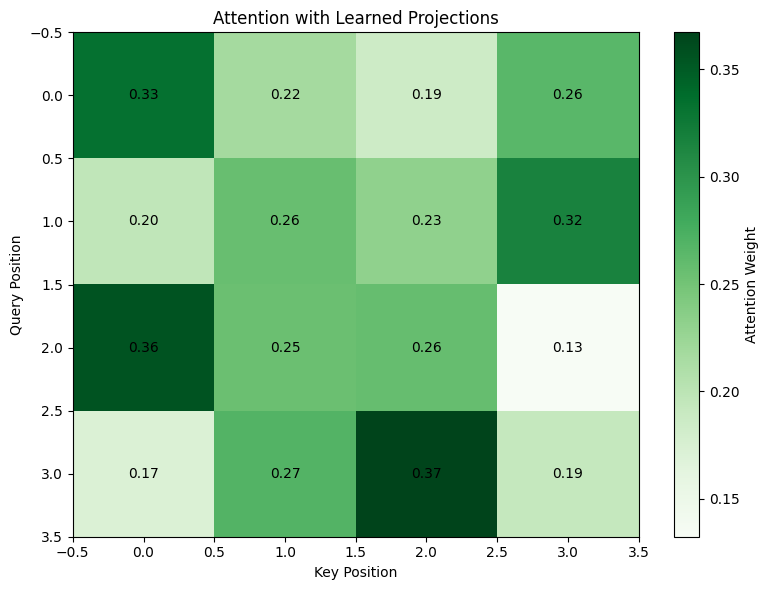

Notice: Different attention pattern because W_Q, W_K, W_V are learned!


In [ ]:
# Cell 10: Apply attention with the projected Q, K, V

# Use our attention function with the newly projected Q, K, V
output_new, weights_new = scaled_dot_product_attention(Q_new, K_new, V_new)

print(f"Attention output shape: {output_new.shape}")
print(f"Attention output:\n{output_new}\n")

# Visualize these new attention patterns
plt.figure(figsize=(8, 6))
plt.imshow(weights_new.detach().numpy(), cmap='Greens', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Attention with Learned Projections')

for i in range(seq_length):
    for j in range(seq_length):
        text = plt.text(j, i, f'{weights_new[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)

plt.tight_layout()
plt.show()

print("Notice: Different attention pattern because W_Q, W_K, W_V are learned!")

In [ ]:
# Cell 11: Introduction to Multi-Head Attention

print("="*60)
print("MULTI-HEAD ATTENTION")
print("="*60)

# Parameters
num_heads = 2  # We'll use 2 heads for simplicity
d_model = 8    # Same as before
d_k = d_model // num_heads  # Each head gets dimension 4

print(f"\nSetup:")
print(f"  Total dimension (d_model): {d_model}")
print(f"  Number of heads: {num_heads}")
print(f"  Dimension per head (d_k): {d_k}")

print(f"\n" + "="*60)
print("Why Multi-Head?")
print("="*60)
print("Single head: Learns ONE type of relationship")
print("  Example: syntactic dependencies")
print("\nMulti-head: Learns MULTIPLE types of relationships in parallel")
print("  Head 1: Maybe syntactic patterns")
print("  Head 2: Maybe semantic patterns")
print("  Head 3: Maybe positional patterns")
print("\nEach head can 'focus' on different aspects!")

MULTI-HEAD ATTENTION

Setup:
  Total dimension (d_model): 8
  Number of heads: 2
  Dimension per head (d_k): 4

Why Multi-Head?
Single head: Learns ONE type of relationship
  Example: syntactic dependencies

Multi-head: Learns MULTIPLE types of relationships in parallel
  Head 1: Maybe syntactic patterns
  Head 2: Maybe semantic patterns
  Head 3: Maybe positional patterns

Each head can 'focus' on different aspects!


In [ ]:
# Cell 12: Create projection matrices for multi-head attention

# For multi-head, we create projections that output (d_model) dimensions
# Then we'll split this into num_heads chunks

W_Q_multi = nn.Linear(d_model, d_model, bias=False)
W_K_multi = nn.Linear(d_model, d_model, bias=False)
W_V_multi = nn.Linear(d_model, d_model, bias=False)

# Project the input
Q_multi = W_Q_multi(X)  # Shape: (4, 8)
K_multi = W_K_multi(X)  # Shape: (4, 8)
V_multi = W_V_multi(X)  # Shape: (4, 8)

print(f"Before splitting into heads:")
print(f"  Q shape: {Q_multi.shape}  # (seq_len, d_model)")
print(f"  K shape: {K_multi.shape}")
print(f"  V shape: {V_multi.shape}")

print(f"\nNow we'll split these into {num_heads} heads...")
print(f"  Each head will have dimension {d_k}")

Before splitting into heads:
  Q shape: torch.Size([4, 8])  # (seq_len, d_model)
  K shape: torch.Size([4, 8])
  V shape: torch.Size([4, 8])

Now we'll split these into 2 heads...
  Each head will have dimension 4


In [ ]:
# Cell 13: Split into multiple heads

# Reshape: (seq_len, d_model) -> (seq_len, num_heads, d_k)
Q_heads = Q_multi.reshape(seq_length, num_heads, d_k)
K_heads = K_multi.reshape(seq_length, num_heads, d_k)
V_heads = V_multi.reshape(seq_length, num_heads, d_k)

print(f"After reshaping:")
print(f"  Q_heads shape: {Q_heads.shape}  # (seq_len, num_heads, d_k)")
print(f"  K_heads shape: {K_heads.shape}")
print(f"  V_heads shape: {V_heads.shape}")

# Transpose to: (num_heads, seq_len, d_k) for easier processing
Q_heads = Q_heads.transpose(0, 1)
K_heads = K_heads.transpose(0, 1)
V_heads = V_heads.transpose(0, 1)

print(f"\nAfter transpose (easier to process):")
print(f"  Q_heads shape: {Q_heads.shape}  # (num_heads, seq_len, d_k)")
print(f"  K_heads shape: {K_heads.shape}")
print(f"  V_heads shape: {V_heads.shape}")

print(f"\nNow we have {num_heads} separate attention heads!")
print(f"  Head 0 - Q shape: {Q_heads[0].shape}")
print(f"  Head 1 - Q shape: {Q_heads[1].shape}")

After reshaping:
  Q_heads shape: torch.Size([4, 2, 4])  # (seq_len, num_heads, d_k)
  K_heads shape: torch.Size([4, 2, 4])
  V_heads shape: torch.Size([4, 2, 4])

After transpose (easier to process):
  Q_heads shape: torch.Size([2, 4, 4])  # (num_heads, seq_len, d_k)
  K_heads shape: torch.Size([2, 4, 4])
  V_heads shape: torch.Size([2, 4, 4])

Now we have 2 separate attention heads!
  Head 0 - Q shape: torch.Size([4, 4])
  Head 1 - Q shape: torch.Size([4, 4])


In [ ]:
# Cell 14: Apply attention to each head independently

# Store outputs from each head
head_outputs = []

for i in range(num_heads):
    # Get Q, K, V for this head
    Q_head = Q_heads[i]  # Shape: (seq_len, d_k)
    K_head = K_heads[i]
    V_head = V_heads[i]

    # Apply attention for this head
    output_head, weights_head = scaled_dot_product_attention(Q_head, K_head, V_head)
    head_outputs.append(output_head)

    print(f"Head {i}:")
    print(f"  Input shape: {Q_head.shape}")
    print(f"  Output shape: {output_head.shape}")
    print(f"  Attention weights shape: {weights_head.shape}")

print(f"\nOutputs shape: {torch.stack(head_outputs).shape}")
print(f"\n✓ Computed attention for {num_heads} heads independently")

Head 0:
  Input shape: torch.Size([4, 4])
  Output shape: torch.Size([4, 4])
  Attention weights shape: torch.Size([4, 4])
Head 1:
  Input shape: torch.Size([4, 4])
  Output shape: torch.Size([4, 4])
  Attention weights shape: torch.Size([4, 4])

Outputs shape: torch.Size([2, 4, 4])

✓ Computed attention for 2 heads independently


In [ ]:
# Cell 15: Concatenate all heads and apply output projection

# Stack outputs: (num_heads, seq_len, d_k)
stacked_outputs = torch.stack(head_outputs)
print(f"Stacked outputs shape: {stacked_outputs.shape}  # (num_heads, seq_len, d_k)")

# Transpose: (num_heads, seq_len, d_k) -> (seq_len, num_heads, d_k)
stacked_outputs = stacked_outputs.transpose(0, 1)
print(f"After transpose: {stacked_outputs.shape}  # (seq_len, num_heads, d_k)")

# Concatenate heads: (seq_len, num_heads, d_k) -> (seq_len, d_model)
concatenated = stacked_outputs.reshape(seq_length, d_model)
print(f"After concatenation: {concatenated.shape}  # (seq_len, d_model)")

# Final output projection
W_O = nn.Linear(d_model, d_model, bias=False)
multi_head_output = W_O(concatenated)

print(f"\nFinal multi-head attention output: {multi_head_output.shape}")
print(f"\n✓ Multi-head attention complete!")
print(f"\nFlow: Input (4,8) -> 2 heads (4,4 each) -> Concat (4,8) -> Output (4,8)")

Stacked outputs shape: torch.Size([2, 4, 4])  # (num_heads, seq_len, d_k)
After transpose: torch.Size([4, 2, 4])  # (seq_len, num_heads, d_k)
After concatenation: torch.Size([4, 8])  # (seq_len, d_model)

Final multi-head attention output: torch.Size([4, 8])

✓ Multi-head attention complete!

Flow: Input (4,8) -> 2 heads (4,4 each) -> Concat (4,8) -> Output (4,8)


In [ ]:
# Cell 16: Multi-Head Attention as a reusable class

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Projection matrices
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def scaled_dot_product_attention(self, Q, K, V):
        d_k = Q.size(-1)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
        attention_weights = F.softmax(scores, dim=-1)
        output = attention_weights @ V
        return output, attention_weights

    def forward(self, x):
        batch_size, seq_len, d_model = x.size()

        # Linear projections
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # Split into heads: (batch, seq_len, d_model) -> (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # Apply attention
        output, attention_weights = self.scaled_dot_product_attention(Q, K, V)

        # Concatenate heads
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        # Final projection
        output = self.W_O(output)

        return output, attention_weights

print("✓ MultiHeadAttention class defined!")

✓ MultiHeadAttention class defined!


In [ ]:
# Cell 17: Test the MultiHeadAttention class

# Create instance
mha = MultiHeadAttention(d_model=8, num_heads=2)

# Add batch dimension to our input: (seq_len, d_model) -> (batch, seq_len, d_model)
X_batch = X.unsqueeze(0)
print(f"Input shape: {X_batch.shape}  # (batch_size, seq_len, d_model)")

# Forward pass
output, attention = mha(X_batch)

print(f"\nOutput shape: {output.shape}")
print(f"Attention shape: {attention.shape}  # (batch, num_heads, seq_len, seq_len)")

print(f"\n✓ Multi-head attention works!")
print(f"\nWe have {num_heads} attention patterns, one per head")
print(f"Head 0 attention shape: {attention[0, 0].shape}")
print(f"Head 1 attention shape: {attention[0, 1].shape}")

Input shape: torch.Size([1, 4, 8])  # (batch_size, seq_len, d_model)

Output shape: torch.Size([1, 4, 8])
Attention shape: torch.Size([1, 2, 4, 4])  # (batch, num_heads, seq_len, seq_len)

✓ Multi-head attention works!

We have 2 attention patterns, one per head
Head 0 attention shape: torch.Size([4, 4])
Head 1 attention shape: torch.Size([4, 4])


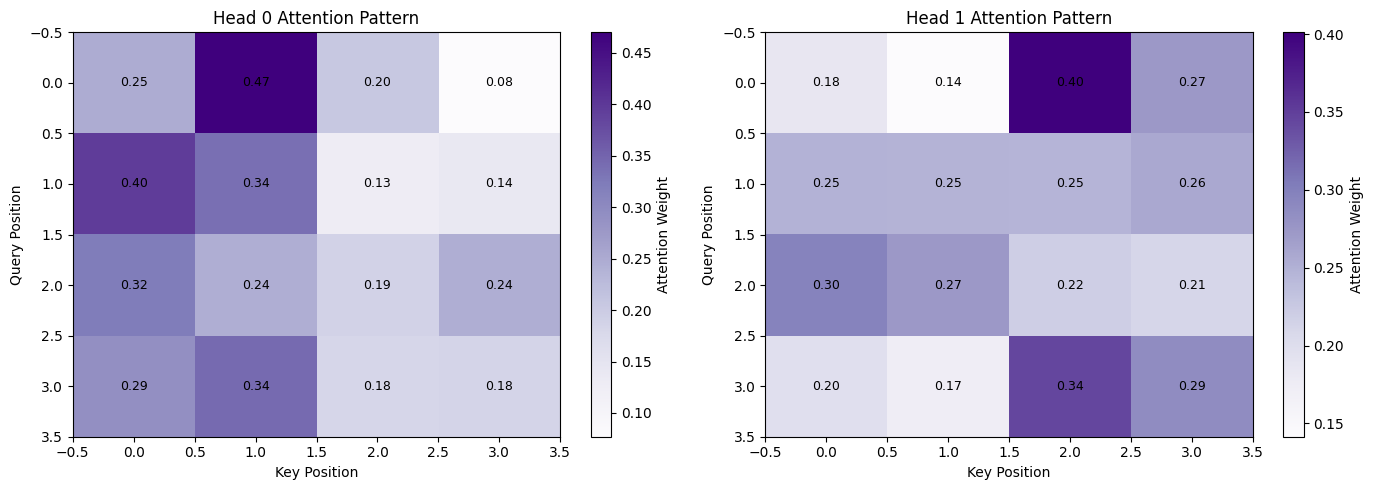

Notice: Each head learns a DIFFERENT attention pattern!
In real transformers, these heads specialize in different relationships


In [ ]:
# Cell 18: Visualize attention from both heads

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for head_idx in range(num_heads):
    ax = axes[head_idx]
    attn = attention[0, head_idx].detach().numpy()

    im = ax.imshow(attn, cmap='Purples', aspect='auto')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    ax.set_title(f'Head {head_idx} Attention Pattern')

    # Add values in cells
    for i in range(seq_length):
        for j in range(seq_length):
            text = ax.text(j, i, f'{attn[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9)

    plt.colorbar(im, ax=ax, label='Attention Weight')

plt.tight_layout()
plt.show()

print("Notice: Each head learns a DIFFERENT attention pattern!")
print("In real transformers, these heads specialize in different relationships")

In [ ]:
# Cell 19: What we learned today

print("="*60)
print("DAY 1 COMPLETE: ATTENTION MECHANISM ✓")
print("="*60)

print("\n📚 What we built from scratch:")
print("  1. ✓ Scaled dot-product attention")
print("  2. ✓ Understanding Q, K, V projections")
print("  3. ✓ Multi-head attention")
print("  4. ✓ Complete MultiHeadAttention class")

print("\n🔑 Key concepts mastered:")
print("  • Why we scale by sqrt(d_k) - variance control!")
print("  • How attention weights are computed (Q @ K^T)")
print("  • Softmax for probability distribution")
print("  • Multiple heads = multiple relationship types")

print("\n📊 Code artifacts:")
print(f"  • scaled_dot_product_attention() function")
print(f"  • MultiHeadAttention class")
print(f"  • Attention visualizations")

print("\n🎯 Next session preview:")
print("  Day 2-3: Build complete Transformer Block")
print("    - Feed-forward networks")
print("    - Layer normalization")
print("    - Residual connections")
print("    - Putting it all together!")

print("\n" + "="*60)
print("Great progress! Save this notebook for future reference.")
print("="*60)

DAY 1 COMPLETE: ATTENTION MECHANISM ✓

📚 What we built from scratch:
  1. ✓ Scaled dot-product attention
  2. ✓ Understanding Q, K, V projections
  3. ✓ Multi-head attention
  4. ✓ Complete MultiHeadAttention class

🔑 Key concepts mastered:
  • Why we scale by sqrt(d_k) - variance control!
  • How attention weights are computed (Q @ K^T)
  • Softmax for probability distribution
  • Multiple heads = multiple relationship types

📊 Code artifacts:
  • scaled_dot_product_attention() function
  • MultiHeadAttention class
  • Attention visualizations

🎯 Next session preview:
  Day 2-3: Build complete Transformer Block
    - Feed-forward networks
    - Layer normalization
    - Residual connections
    - Putting it all together!

Great progress! Save this notebook for future reference.
